# Final Prediction
## Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = pd.read_csv('../data/final_project.csv',header=0)

In [3]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1


In [4]:
df.shape

(160000, 51)

In [16]:
print("Numeric columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df.select_dtypes(include=['object', 'category']).columns.tolist())


Numeric columns: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x25', 'x26', 'x27', 'x28', 'x31', 'x33', 'x34', 'x35', 'x36', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'y']
Categorical columns: ['x24', 'x29', 'x30', 'x32', 'x37']


In [21]:
df_num = df.select_dtypes(include='number')
df_cat = df.select_dtypes(include='object')

df_num.head()


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1


In [23]:
df_cat.head()

,x24,x29,x30,x32,x37
0,euorpe,July,tuesday,0.0%,$1313.96
1,asia,Aug,wednesday,-0.02%,$1962.78
2,asia,July,wednesday,-0.01%,$430.47
3,asia,July,wednesday,0.01%,$-2366.29
4,asia,July,tuesday,0.01%,$-620.66


In [28]:
df.x32.value_counts()

x32
0.01%     40767
-0.01%    34094
0.0%      33923
-0.0%     30492
-0.02%     9924
0.02%      7987
-0.03%     1727
0.03%       855
-0.04%      138
0.04%        55
-0.05%        6
0.05%         1
Name: count, dtype: int64

- Data has 160,000 rows (which consider small)
- Data has 51 features range from x0 to x49.
- Data has 45 input features are numeric and 5 features are categorical
- The final feature y is the label, that contains only 2 values 0 and 1.
- Categorical values likely contains: Continent (x24), Month (x29), Days of Week (x30), Percentage (x32) and Currency in $ (x37)
- This is Supervised Learning model with binary output

## EDA
### Missing values

In [6]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)

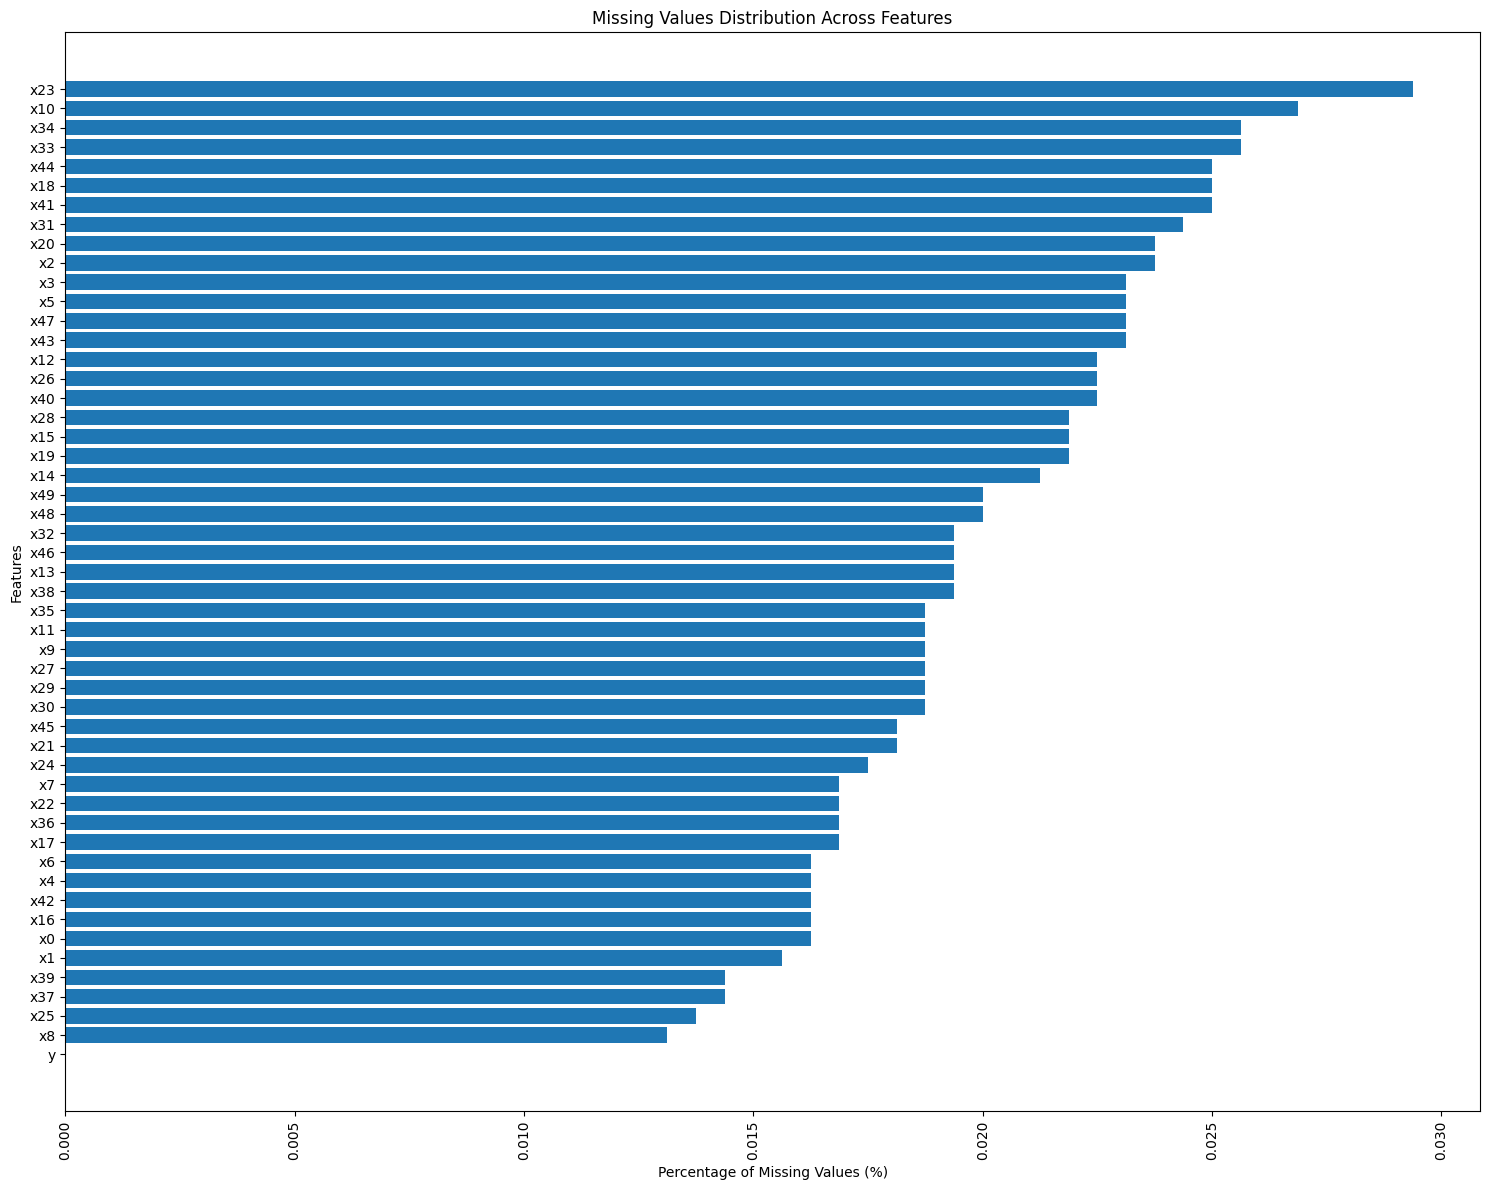

In [8]:
# Create the plot
plt.figure(figsize=(15, 12))
plt.barh(missing.index, missing.Percentage)
plt.xticks(rotation=90)
plt.title('Missing Values Distribution Across Features')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.tight_layout()
# Save the plot
plt.savefig('../report/plots/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

- There are many features having missing values
- The feature x23 has largest percentage of missing values at 0.03%
- The target variable **y** doesn't have missing values


### Imputation
- With the small amount of missing values, we can simply impute the numeric value with KNNImputer and the categorical value with most frequency.
- The categorical value having $ amount x37 could be converted to numeric before applying imputation
#### Impute numeric values

In [ ]:
from sklearn.impute import KNNImputer
Kimputer = KNNImputer(n_neighbors=5, weights='uniform')

In [41]:
df.x37 = df.x37.replace('\$', '', regex=True).astype(float)

In [42]:
df_num = df.select_dtypes(include='number')


In [ ]:
df_num_imputed = pd.DataFrame(Kimputer.fit_transform(df_num), columns=df_num.columns)
df_num_imputed.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0.0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0.0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0.0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0.0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1.0


#### Impute categorical values
- Impute with None

In [55]:
df_cat = df.select_dtypes(include='object')
df_cat.head()

,x24,x29,x30,x32
0,euorpe,July,tuesday,0.0%
1,asia,Aug,wednesday,-0.02%
2,asia,July,wednesday,-0.01%
3,asia,July,wednesday,0.01%
4,asia,July,tuesday,0.01%


In [ ]:
Cimputer = SimpleImputer(strategy='most_frequent')

In [67]:
df[['x24']] = Cimputer.fit_transform(df[['x24']])
df[['x29']] = Cimputer.fit_transform(df[['x29']])
df[['x32']] = Cimputer.fit_transform(df[['x32']])
df[['x30']] = Cimputer.fit_transform(df[['x30']])



### Distribution of Label values
- The bar plot shows that 60% are for label 1 and 40% are for label 0
- They are consider good enough distribution

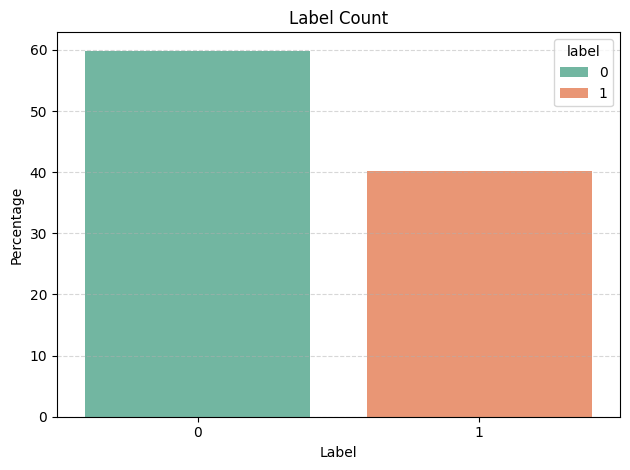

<Figure size 640x480 with 0 Axes>

In [76]:
# Convert value_counts to DataFrame
label_counts = df['y'].value_counts().reset_index()
label_counts.columns = ['label', 'count']
label_counts['percentage'] = (label_counts['count'] / label_counts['count'].sum()) * 100

# Plot using seaborn
sns.barplot(data=label_counts, x='label', y='percentage', hue='label', palette='Set2')
plt.title('Label Count')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('../report/plots/label_count.png', dpi=300, bbox_inches='tight')



### Distribution of 4 categorical data

In [77]:
def plot_categorical_grid(df, cat_cols,nrot, target_col='y', n_rows=2, n_cols=2):
    # Set up figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,16))
    axes = axes.flatten()

    # Define color mapping
    expected_order = [1, 0]
    colors = sns.color_palette("Set2")
    #colors = {1: "red", 0: "blue"}

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        
        # Build count DataFrame
        count_df = (
            df.groupby([col, target_col])
            .size()
            .reset_index(name='count')
            .pivot(index=col, columns=target_col, values='count')
            .fillna(0)
        )

        # Sort by total count descending
        count_df['total'] = count_df.sum(axis=1)
        count_df = count_df.sort_values(by='total', ascending=False).drop(columns='total')

        # Normalize to get proportions
        total_count = count_df.values.sum()
        prop_df = count_df / total_count * 100

        # Reorder columns to expected order
        available_order = [t for t in expected_order if t in prop_df.columns]
        prop_df = prop_df[available_order]

        # Plot
        prop_df.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            color=[colors[c] for c in available_order],
            legend=False
        )

        ax.set_title(col)
        ax.set_ylabel("Proportion (%)")
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=15,rotation=nrot)
        ax.tick_params(axis='y', labelsize=15)

    # Shared legend
    axes[-1].legend(loc='upper right', fontsize='medium', frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('../report/plots/cat_grid.png', dpi=300, bbox_inches='tight')

    plt.show()


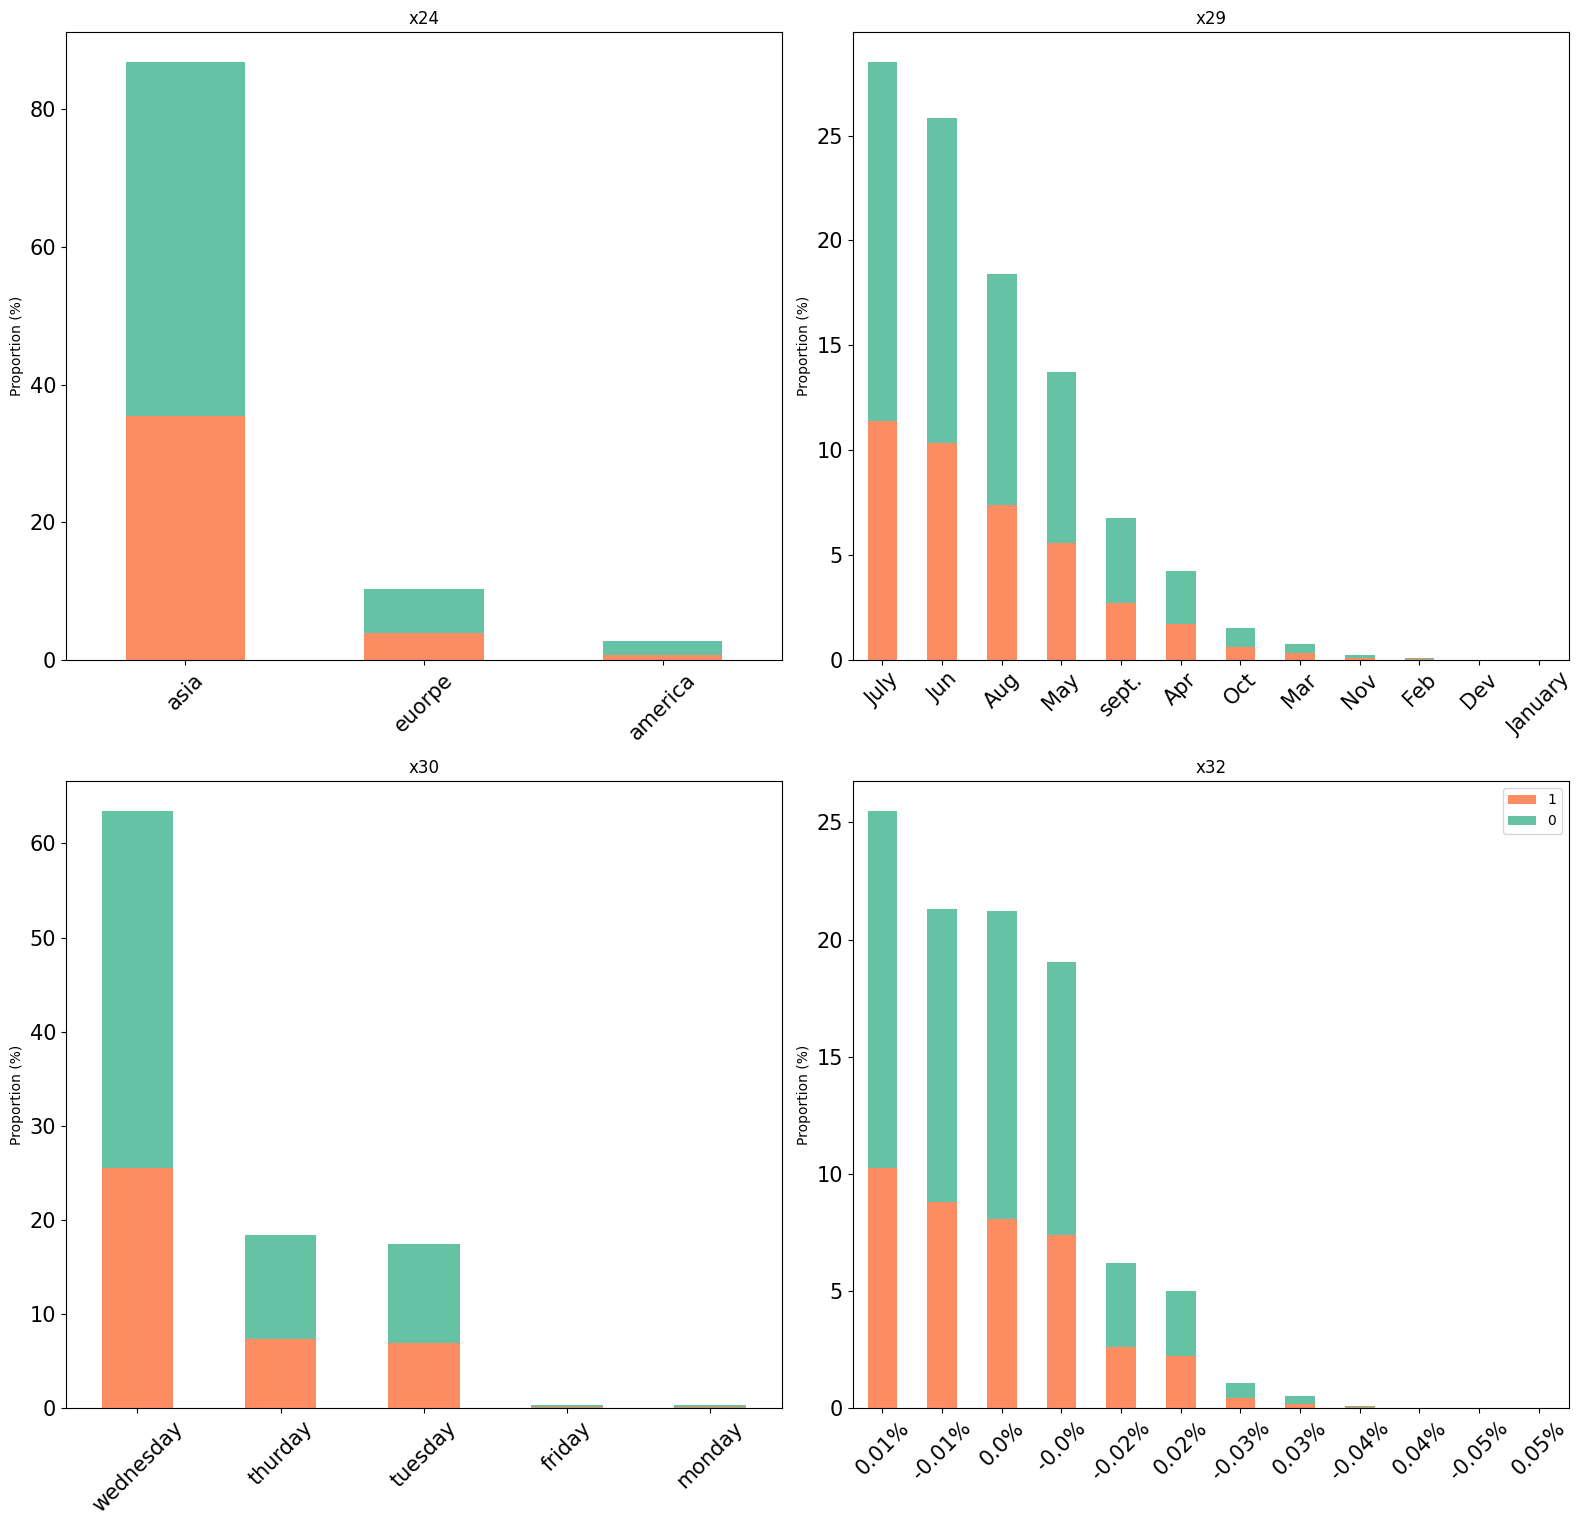

In [ ]:
plot_categorical_grid(df, ['x24', 'x29', 'x30', 'x32'],45)

- **x24**: 85% incident occured in Asia while only 10% in Europe and 5% in America. No other continent found.
- **x29**: Summer (June, July, August) have most of the incidents occured with the summation of more than 75%
- **x30**: Most incidents occured during weekday with the highest one on Wednesday. No incident occured on weekend and the Monday/Friday have very low attendence
- The percentage in **x32** show minor changes with 90% changes are from the range of 0.0% to 0.01%
- We can infer that this is the cross continent summer holiday travel data

To use this categorical data, we need to apply One Hot Encoding to it:

In [212]:
df_cat_ohe = pd.get_dummies(df[['x24', 'x29', 'x30', 'x32']],drop_first=False,dtype=int)


### Cross Correlation Analysis

- Calculate the cross correlation between 46 numeric features
- Sort list the strong correlation pairs with R>0.8


In [124]:
X = df_num_imputed.drop(columns=['y'])

### VIF


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept) for VIF calculation
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]


In [126]:
cnew = vif_data[vif_data['VIF']>10]
cnew

,Feature,VIF
2,x2,34126.355432
6,x6,34057.358852
7,x7,12478.838091
12,x12,3195.499162
20,x20,1897.794550
23,x23,2244.924924
26,x27,3896.319704
27,x28,1167.484493
33,x37,102.599354
34,x38,18737.463814


In [128]:
X_new = X[cnew['Feature']]

In [129]:
corr = X_new.corr(method="pearson")

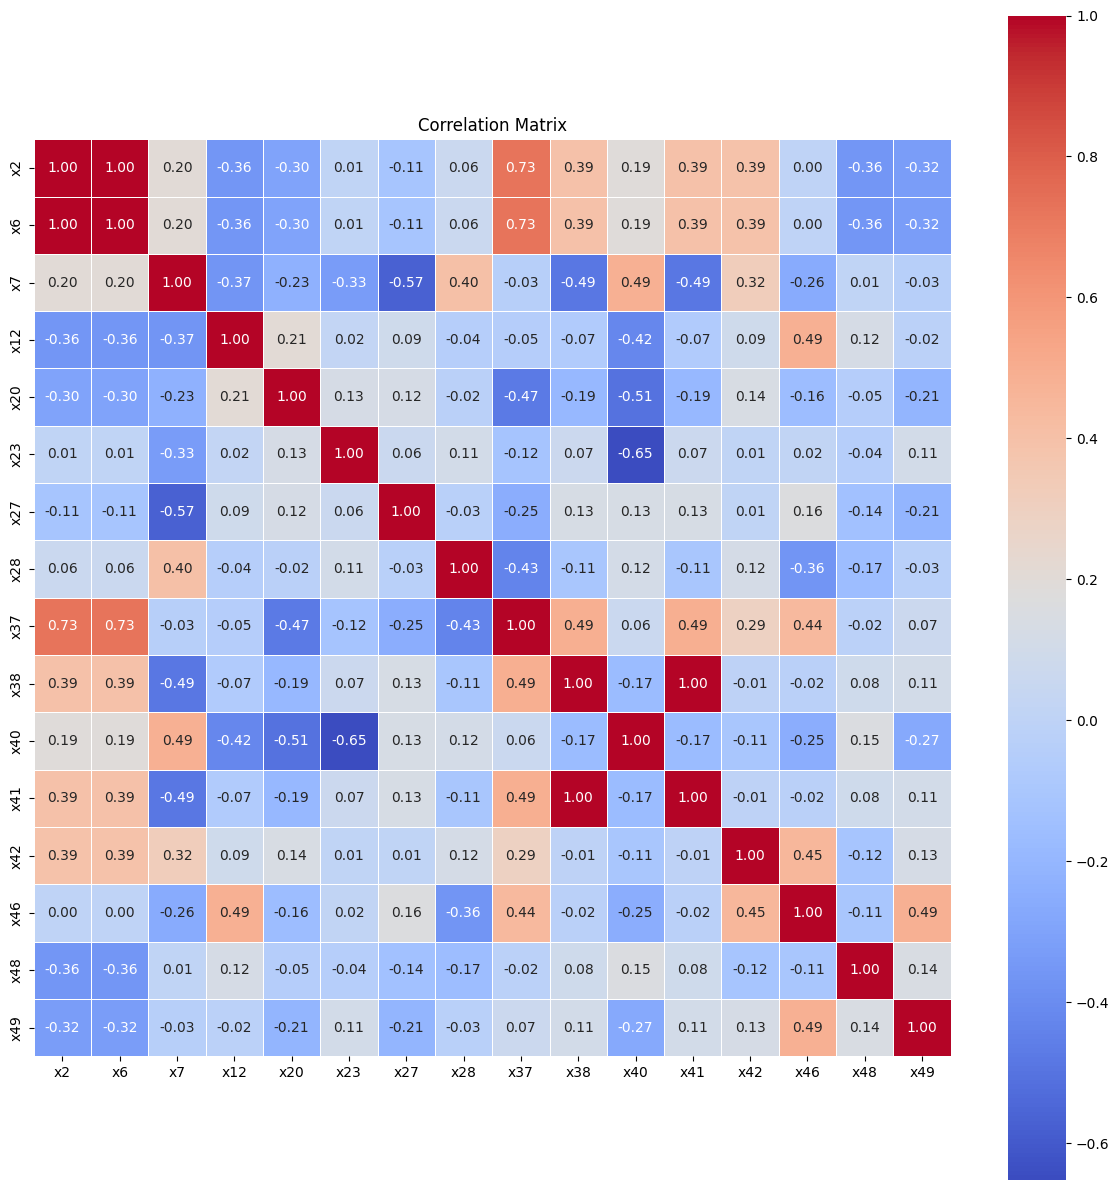

In [130]:
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig('../report/plots/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

- Out of 46 numeric features only 4 pairs have high enough correlation more than 0.7
- There may exists some collinearity between the pair of (x2, x6) and (x38, x41)
- High VIF features did not exhibit high cross correlation, except pair (x2,x6) and (x38,x41)
- We will remove x6 and x41 for the calculation

In [131]:
X_num = X.drop(columns=['x6', 'x41'])

### Distribution of numerical features

IndexError: index 44 is out of bounds for axis 0 with size 44

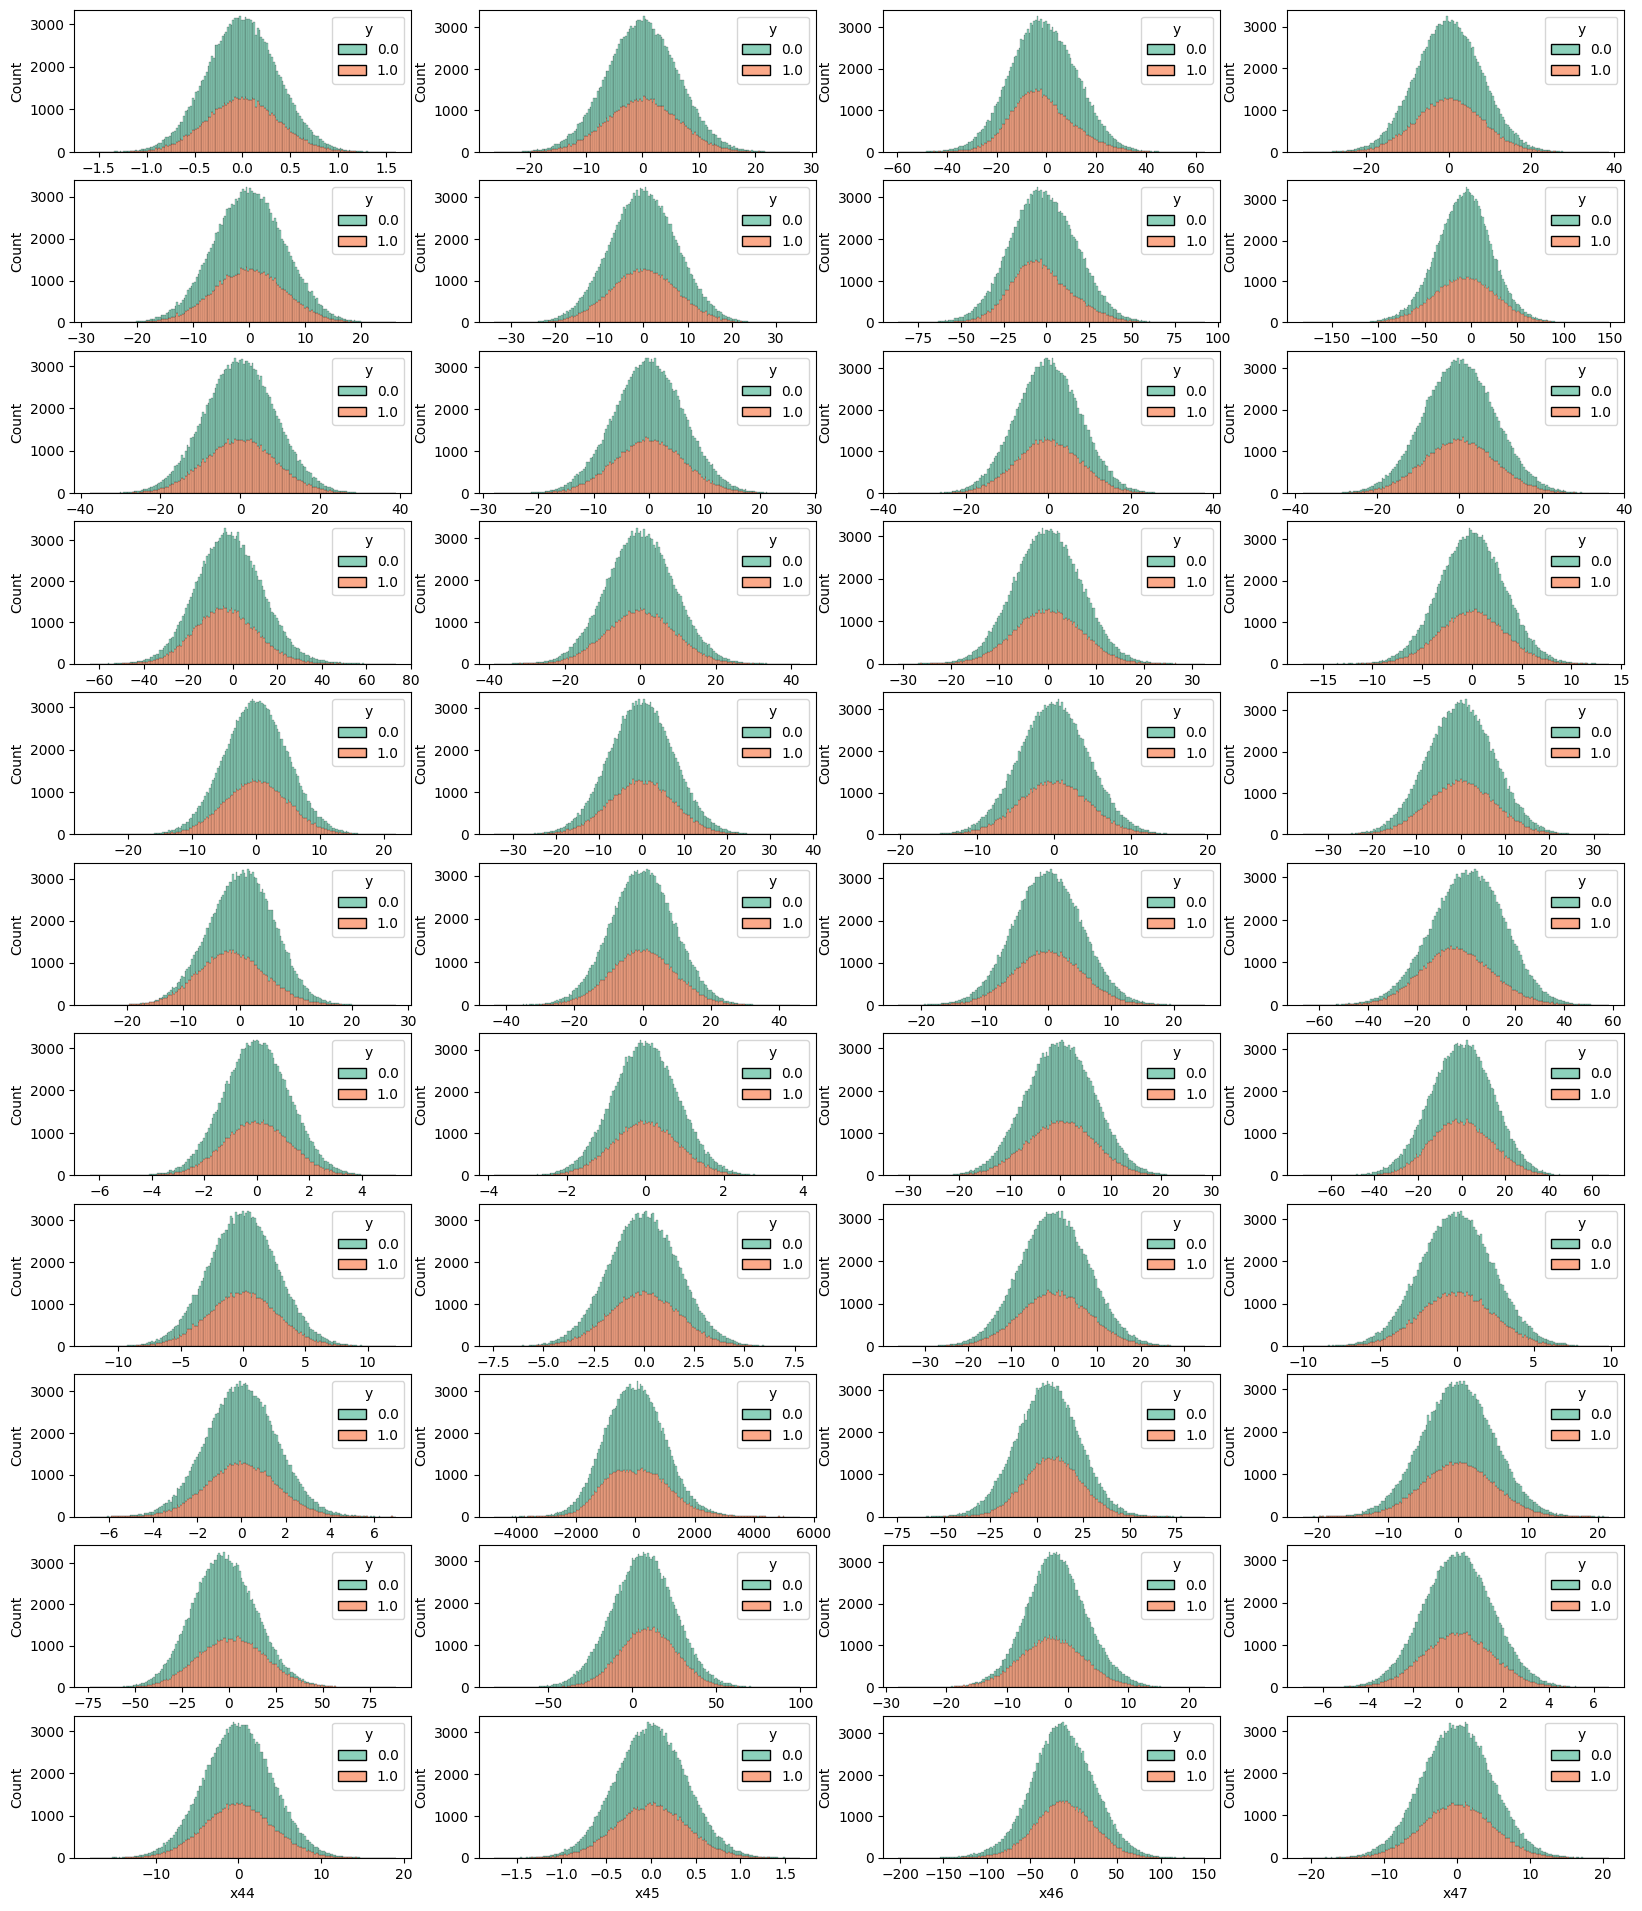

In [208]:
# Create subplots
fig, axes = plt.subplots(11, 4, figsize=(20, 24))
axes = axes.flatten()
palette = sns.color_palette("Set2", 44)

# Plot each histogram in a subplot
for i, column in enumerate(df_num_imputed.columns):
    sns.histplot(data = df_num_imputed,
                x=column,
                palette='Set2',
                ax=axes[i],
                hue='y',
                multiple='stack',
                legend=True)
plt.tight_layout()
plt.savefig('../report/plots/hist_num.png', dpi=300, bbox_inches='tight')
plt.show()


- Histogram plots show all numeric input features having Gaussian distribution with bell shape.
- The scale are different thought but if we are using tree-based model, there is no need to scale it

In [214]:
X = pd.merge(X_num, df_cat_ohe,left_index=True, right_index=True)

In [215]:
X.head()

,x0,x1,x2,x3,x4,x5,x7,x8,x9,x10,...,x32_-0.02%,x32_-0.03%,x32_-0.04%,x32_-0.05%,x32_0.0%,x32_0.01%,x32_0.02%,x32_0.03%,x32_0.04%,x32_0.05%
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,-14.789997,-1.040673,-4.204950,6.187465,...,0,0,0,0,1,0,0,0,0,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,-6.725709,0.896421,0.330165,-11.708859,...,1,0,0,0,0,0,0,0,0,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,11.060572,5.325880,-2.632984,1.572647,...,0,0,0,0,0,0,0,0,0,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-18.913592,-0.337041,-5.568076,-2.000255,...,0,0,0,0,0,1,0,0,0,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,27.532281,1.199715,-4.309105,6.667530,...,0,0,0,0,0,1,0,0,0,0


In [216]:
y = df['y']

## Modeling with RF
RF and XGBoost are tree-based model hence does not really require feature selection


In [217]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

### Modeling RF1: Using entire data

In [223]:
%%time
from sklearn.model_selection import GridSearchCV
# Define parameter grid
rf = RandomForestClassifier(n_estimators=25,random_state=123)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_features': [5,10,15,20],
    'max_depth': [None, 1,3,5,7,9],
    'min_samples_split': [8,6,4],
    'min_samples_leaf': [4,2,1],
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit to your data
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

In [220]:
model_rf_all = RandomForestClassifier(n_estimators=100,random_state=123)
model_rf_all.fit(X_train,y_train)


RandomForestClassifier(random_state=123)

In [221]:

y_pred = model_rf_all.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     19218
           1       0.93      0.86      0.89     12782

    accuracy                           0.92     32000
   macro avg       0.92      0.91      0.91     32000
weighted avg       0.92      0.92      0.92     32000

[[18411   807]
 [ 1787 10995]]
0.9189375


### Find the optimal hyperparameters

### Important variables
- Plot 2 figures for feature importances for full and selected data

In [222]:
# Get feature importances
importances_selected  = model_rf_selected.feature_importances_
features = X_selected_train.columns
importances_full = model_rf_all.feature_importances_
features_full = X_train.columns 

# Display top features
importance_df_selected = pd.DataFrame({'Feature': features, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


NameError: name 'model_rf_selected' is not defined

### XGBoost model - All data
- Cross Validation

In [ ]:
params = {
    'subsample': 0.75,
    'max_depth': 4,
    'eval_metric': 'auc',
    'objective': 'binary:logistic'
}

def XGBRandomSearch(params, data, n_iter=30):
    best_score = 0
    best_params = 'error'

    max_d = np.random.choice([2, 4, 6, 8, 10, 12, 15, 20], n_iter)
    subs = 0.5 + np.random.random(n_iter) / 2
    colsample_bytree = 0.5 + np.random.random(n_iter) / 2
    colsample_bylevel = 0.5 + np.random.random(n_iter) / 2
    colsample_bynode = 0.5 + np.random.random(n_iter) / 2

    for i in range(n_iter):
        params['subsample'] = subs[i]
        params['max_depth'] = max_d[i]
        params['colsample_bytree'] = colsample_bytree[i]
        params['colsample_bylevel'] = colsample_bylevel[i]
        params['colsample_bynode'] = colsample_bynode[i]

        f = xgb.cv(
            params, 
            dtrain=data, 
            nfold=5,
            stratified=True, 
            metrics='auc',
            num_boost_round=1000, 
            early_stopping_rounds=10
        )

        if f.shape[0] == 1000:
            print("Warning hit limit")
        print(params, f['test-auc-mean'].max())

        if f['test-auc-mean'].max() > best_score:
            best_score = f['test-auc-mean'].max()
            best_params = copy.deepcopy(params)

    return f, best_score, best_params


In [ ]:
traindata = xgb.DMatrix(X_train, label=y_train)
testdata = xgb.DMatrix(X_test, label=y_test)

In [ ]:
%%time
b = xgb.train(params,evals=[(traindata,'train'),(testdata,'test')],num_boost_round=1000,dtrain=traindata,early_stopping_rounds=10)

[0]	train-auc:0.77346	test-auc:0.74402
[1]	train-auc:0.79488	test-auc:0.76707
[2]	train-auc:0.80419	test-auc:0.77930
[3]	train-auc:0.82998	test-auc:0.80348
[4]	train-auc:0.84099	test-auc:0.80988
[5]	train-auc:0.84831	test-auc:0.81260
[6]	train-auc:0.85693	test-auc:0.82317
[7]	train-auc:0.85693	test-auc:0.82155
[8]	train-auc:0.86491	test-auc:0.83029
[9]	train-auc:0.87085	test-auc:0.83847
[10]	train-auc:0.88055	test-auc:0.85022
[11]	train-auc:0.88851	test-auc:0.85713
[12]	train-auc:0.89331	test-auc:0.86225
[13]	train-auc:0.90014	test-auc:0.87325
[14]	train-auc:0.90574	test-auc:0.87882
[15]	train-auc:0.91018	test-auc:0.88311
[16]	train-auc:0.91333	test-auc:0.88549
[17]	train-auc:0.91607	test-auc:0.88807
[18]	train-auc:0.91885	test-auc:0.88864
[19]	train-auc:0.92023	test-auc:0.88920
[20]	train-auc:0.92205	test-auc:0.88977
[21]	train-auc:0.92532	test-auc:0.89277
[22]	train-auc:0.92844	test-auc:0.89557
[23]	train-auc:0.92991	test-auc:0.89585
[24]	train-auc:0.93640	test-auc:0.90067
[25]	train

In [ ]:
%%time 
result = XGBRandomSearch(params,traindata,n_iter=30)

{'subsample': 0.9849140019698497, 'max_depth': 20, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.5939185178356372, 'colsample_bylevel': 0.6240925887932987, 'colsample_bynode': 0.623080447309478} 0.9450575930272995
{'subsample': 0.6737275067322246, 'max_depth': 15, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8595510526851826, 'colsample_bylevel': 0.8751467797120593, 'colsample_bynode': 0.6786205009413164} 0.938294182060333
{'subsample': 0.7355110399806033, 'max_depth': 12, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8912971127690165, 'colsample_bylevel': 0.6628028253683611, 'colsample_bynode': 0.7430786573458059} 0.9437921189014725
{'subsample': 0.7240812536153072, 'max_depth': 4, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.905645188452515, 'colsample_bylevel': 0.7288332211098147, 'colsample_bynode': 0.7319531639977572} 0.9277596982662478
{'subsample': 0.66742379

In [ ]:
result

(     train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
 0          0.795121       0.006812       0.754227      0.016118
 1          0.857260       0.012607       0.785829      0.012482
 2          0.890048       0.011890       0.802089      0.016046
 3          0.926144       0.005612       0.828054      0.011691
 4          0.941919       0.006533       0.841270      0.014232
 ..              ...            ...            ...           ...
 126        1.000000       0.000000       0.934419      0.004446
 127        1.000000       0.000000       0.934458      0.004438
 128        1.000000       0.000000       0.934535      0.004408
 129        1.000000       0.000000       0.934509      0.004318
 130        1.000000       0.000000       0.934586      0.004371
 
 [131 rows x 4 columns],
 0.9488448962383369,
 {'subsample': 0.9810210273543551,
  'max_depth': 15,
  'eval_metric': 'auc',
  'objective': 'binary:logistic',
  'colsample_bytree': 0.8491714220797353,
  'colsample_bylev

In [ ]:
%%time

# Train XGBoost classifier
model_xgb = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='auc',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=15,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=123           # for reproducibility
)

model_xgb.fit(X_train, y_train)

# Make predictions
y_pred = model_xgb.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      8285
         1.0       0.89      0.36      0.52       396

    accuracy                           0.97      8681
   macro avg       0.93      0.68      0.75      8681
weighted avg       0.97      0.97      0.96      8681

[[8267   18]
 [ 252  144]]
0.9688975924432669
CPU times: user 1min 56s, sys: 1.01 s, total: 1min 57s
Wall time: 3.29 s


## XGBoost
### Selected data

In [ ]:
traindata_selected = xgb.DMatrix(X_selected_train, label=y_selected_train)
testdata_selected = xgb.DMatrix(X_selected_test, label=y_selected_test)

In [ ]:
%%time 
b = xgb.train(params,evals=[(traindata_selected,'train'),(testdata_selected,'test')],num_boost_round=1000,dtrain=traindata_selected,early_stopping_rounds=10)

[0]	train-auc:0.75414	test-auc:0.72629
[1]	train-auc:0.78393	test-auc:0.73028
[2]	train-auc:0.80688	test-auc:0.73291
[3]	train-auc:0.83002	test-auc:0.73076
[4]	train-auc:0.84965	test-auc:0.72987
[5]	train-auc:0.87177	test-auc:0.73066
[6]	train-auc:0.89222	test-auc:0.73191
[7]	train-auc:0.91196	test-auc:0.72976
[8]	train-auc:0.92851	test-auc:0.73061
[9]	train-auc:0.93533	test-auc:0.73195
[10]	train-auc:0.94488	test-auc:0.73096
[11]	train-auc:0.95446	test-auc:0.73230
[12]	train-auc:0.95968	test-auc:0.73571
[13]	train-auc:0.96652	test-auc:0.73677
[14]	train-auc:0.97222	test-auc:0.73977
[15]	train-auc:0.97505	test-auc:0.74172
[16]	train-auc:0.97745	test-auc:0.74274
[17]	train-auc:0.97903	test-auc:0.74511
[18]	train-auc:0.98206	test-auc:0.74074
[19]	train-auc:0.98523	test-auc:0.74303
[20]	train-auc:0.98868	test-auc:0.74272
[21]	train-auc:0.98936	test-auc:0.74512
[22]	train-auc:0.99060	test-auc:0.74535
[23]	train-auc:0.99156	test-auc:0.74766
[24]	train-auc:0.99243	test-auc:0.75090
[25]	train

In [ ]:
%%time
result = XGBRandomSearch(params,traindata_selected,n_iter=30)

{'subsample': 0.5435646498507704, 'max_depth': 10, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8353189348090797, 'colsample_bylevel': 0.5195938961271603, 'colsample_bynode': 0.7880786672089184} 0.7572879374759448
{'subsample': 0.5101091987201629, 'max_depth': 20, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.6051912805369204, 'colsample_bylevel': 0.6414034812882048, 'colsample_bynode': 0.7960209656359195} 0.7334081424787827
{'subsample': 0.916309922773969, 'max_depth': 12, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.5644631488274267, 'colsample_bylevel': 0.5600982806065844, 'colsample_bynode': 0.7861259528954367} 0.766967453947149
{'subsample': 0.8890783754749252, 'max_depth': 2, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.6577141754620919, 'colsample_bylevel': 0.6480700987610725, 'colsample_bynode': 0.6115408163203091} 0.7702477741082351
{'subsample': 0.9350060

In [ ]:
result

(    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
 0         0.681526       0.003658       0.677144      0.011365
 1         0.706593       0.007837       0.703334      0.013325
 2         0.724116       0.004664       0.714912      0.015741
 3         0.733531       0.003212       0.723927      0.018074
 4         0.736908       0.001479       0.725266      0.015725
 5         0.738233       0.002311       0.726756      0.014739
 6         0.739835       0.002608       0.729254      0.014361
 7         0.741700       0.001078       0.730566      0.017161
 8         0.743938       0.002099       0.733043      0.017569
 9         0.746459       0.001920       0.734684      0.017792
 10        0.749484       0.002207       0.736419      0.018516
 11        0.751931       0.003100       0.738015      0.018578
 12        0.753522       0.003386       0.740250      0.017024
 13        0.756799       0.003411       0.741505      0.016686
 14        0.758684       0.003506      

In [ ]:
%%time

# Train XGBoost classifier
model_xgb_selected = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='auc',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=15,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=123           # for reproducibility
)

model_xgb_selected.fit(X_selected_train, y_selected_train)

# Make predictions
y_pred = model_xgb_selected.predict(X_selected_test)

print(classification_report(y_selected_test,y_pred))
print(confusion_matrix(y_selected_test,y_pred))
print(accuracy_score(y_selected_test,y_pred))


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      8285
         1.0       0.17      0.03      0.05       396

    accuracy                           0.95      8681
   macro avg       0.56      0.51      0.51      8681
weighted avg       0.92      0.95      0.93      8681

[[8227   58]
 [ 384   12]]
0.9490842068886073
CPU times: user 1min 21s, sys: 1.45 s, total: 1min 23s
Wall time: 2.35 s


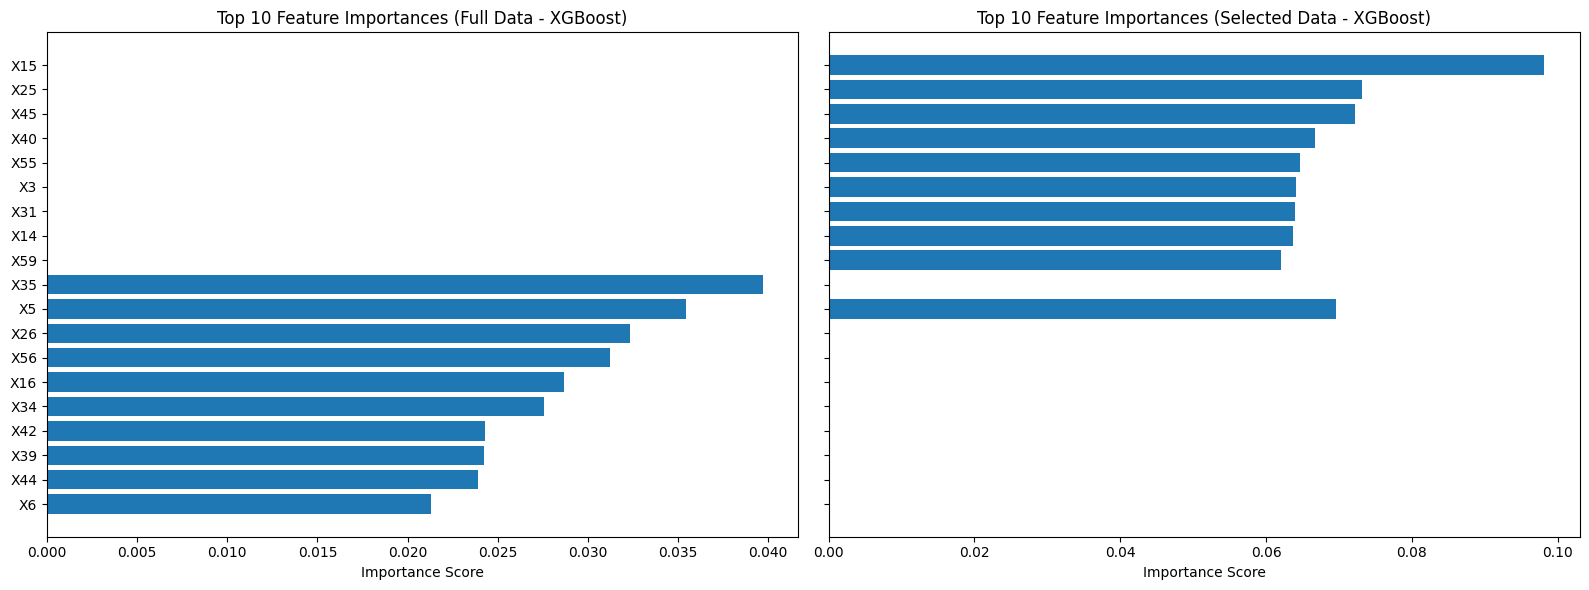

In [ ]:
# Get feature importances
importances_full = model_xgb.feature_importances_
features_full = X_train.columns

importances_selected = model_xgb_selected.feature_importances_
features_selected = X_selected_train.columns

# Create DataFrames
importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_selected = pd.DataFrame({'Feature': features_selected, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data - XGBoost)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data - XGBoost)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

### Comparative ROC between RF and XGBoost
- We have 4 models and now we will compare accuracy score and AUC score

#### 4. Get prediction probabilities




In [ ]:
y_RF_Full = model_rf_all.predict_proba(X_test)[:, 1]
y_RF_sel = model_rf_selected.predict_proba(X_selected_test)[:, 1]
y_XGB_Full = model_xgb.predict_proba(X_test)[:, 1]
y_XGB_sel = model_xgb_selected.predict_proba(X_selected_test)[:, 1]

In [ ]:
ypred_all = pd.DataFrame([y_RF_Full,y_RF_sel,y_XGB_Full,y_XGB_sel]).T

In [ ]:
ypred_all.columns = ["RF_Full","RF_Selected","XGB_Full","XGB_Selected"]

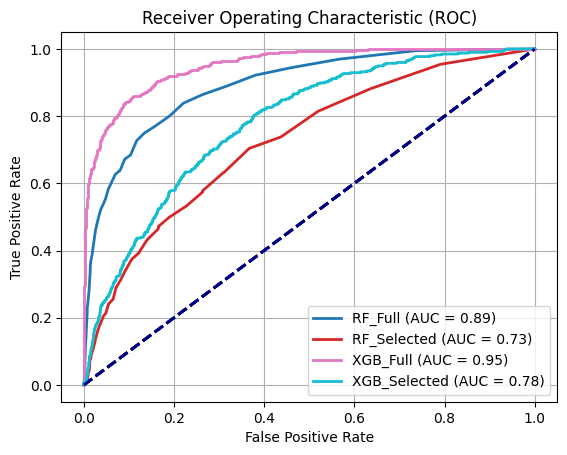

In [ ]:
plt.figure()
colors = plt.cm.tab10(np.linspace(0, 1, len(ypred_all.columns)))

for i,yi in enumerate(ypred_all.columns):

    fpr, tpr, thresholds = roc_curve(y_test, ypred_all[yi])
    roc_auc = auc(fpr, tpr)   
    
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{yi} (AUC = {roc_auc:.2f})')    
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.grid(True)
plt.show()

### 5. Classification report

In [ ]:
y_pred_rf_full = model_rf_all.predict(X_test)
y_pred_rf_sel  = model_rf_selected.predict(X_selected_test)
y_pred_xgb_full = model_xgb.predict(X_test)
y_pred_xgb_sel  = model_xgb_selected.predict(X_selected_test)



In [ ]:
report_rf_full = classification_report(y_test,y_pred_rf_full,output_dict=True)
report_rf_sel  = classification_report(y_test,y_pred_rf_sel,output_dict=True)
report_xgb_full = classification_report(y_test,y_pred_xgb_full,output_dict=True)
report_xgb_sel  = classification_report(y_test,y_pred_xgb_sel,output_dict=True)

In [ ]:
print(classification_report(y_test,y_pred_rf_full))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      8285
         1.0       0.56      0.07      0.12       396

    accuracy                           0.96      8681
   macro avg       0.76      0.53      0.55      8681
weighted avg       0.94      0.96      0.94      8681



In [ ]:
print(classification_report(y_test,y_pred_xgb_full))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      8285
         1.0       0.89      0.36      0.52       396

    accuracy                           0.97      8681
   macro avg       0.93      0.68      0.75      8681
weighted avg       0.97      0.97      0.96      8681



In [ ]:
print(classification_report(y_test,y_pred_rf_sel))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      8285
         1.0       0.05      0.01      0.01       396

    accuracy                           0.95      8681
   macro avg       0.50      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681



In [ ]:
print(classification_report(y_test,y_pred_xgb_sel))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      8285
         1.0       0.17      0.03      0.05       396

    accuracy                           0.95      8681
   macro avg       0.56      0.51      0.51      8681
weighted avg       0.92      0.95      0.93      8681

